In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import train_test_split

In [3]:
employee = pd.read_csv("datasets/employee_turnover.csv")
employee_df = employee.copy()

In [4]:
employee.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


<Axes: xlabel='Training_Hours', ylabel='Employee_Turnover'>

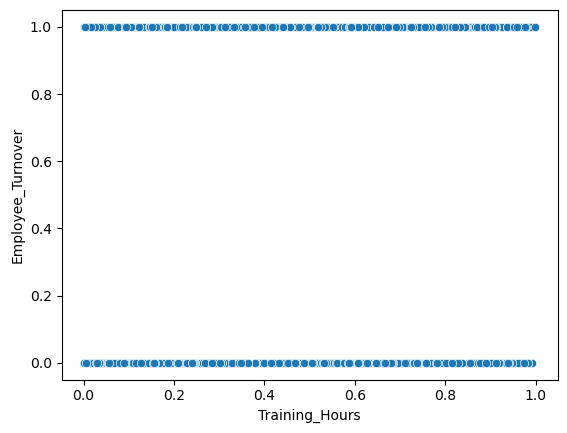

In [71]:
sns.scatterplot(data=employee, x="Training_Hours", y="Employee_Turnover")

In [5]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

In [28]:
# remove duplicates
# employee[employee.duplicated()]
employee = employee.drop_duplicates()

In [30]:
# Input and output split
X = employee.drop(columns=["Employee_Turnover"], axis=1)
y = employee["Employee_Turnover"]

In [108]:
# Testing and training split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state=42)

In [109]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [110]:
# prediction for testing data
y_test_predicted = model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_predicted)
precision = precision_score(y_test, y_test_predicted)
print("Accuracy score:", accuracy)
print("Precision socre:", precision)

Accuracy score: 0.8444444444444444
Precision socre: 0.9090909090909091


In [111]:
# prediction for training data
y_train_predicted = model.predict(X_train)

accuracy_train = accuracy_score(y_train, y_train_predicted)
precision_train = precision_score(y_train, y_train_predicted)
print("Accuracy score:", accuracy_train)
print("Precision socre:", precision_train)

Accuracy score: 0.8784313725490196
Precision socre: 0.8793565683646113
